In [ ]:
#필요 라이브러리
!pip install scikit-learn pandas numpy seaborn matplotlib

In [ ]:
#데이터 불러오기
from sklearn.datasets import fetch_openml
X,y=fetch_openml('adult',version=2, as_frame=True, return_X_y=True)

In [3]:
#데이터 기본 전처리
import pandas as pd
df=X.copy()
df['income']=y
df=df[['age','workclass','education','education-num','marital-status','occupation',
       'race','sex','capital-gain','capital-loss','hours-per-week','income']]
df=df.dropna()


[PMF of education]
education
HS-grad         0.325245
Some-college    0.218018
Bachelors       0.168835
Masters         0.056264
Assoc-voc       0.042969
11th            0.035431
Assoc-acdm      0.033215
10th            0.026915
7th-8th         0.018335
Prof-school     0.017596
9th             0.014924
12th            0.013012
Doctorate       0.012513
5th-6th         0.010167
1st-4th         0.004975
Preschool       0.001586
Name: proportion, dtype: float64


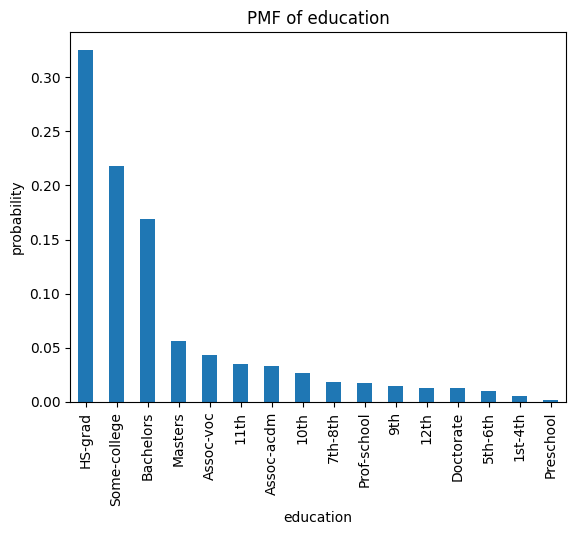

In [11]:
#확률질량함수 1: 최종 학력
import matplotlib.pyplot as plt

print('\n[PMF of education]')
education_dist=df['education'].value_counts(normalize=True) #value_counts()->각 항목이 몇 번 등장하는지 세기 
print(education_dist)                                       #normalize=True->전체 개수에서 해당 항목이 차지하는 비율(확률) 계산


plt.figure() #흰 바탕 만들기
education_dist.plot(kind='bar') #막대 그래프
plt.title('PMF of education')
plt.ylabel('probability')
plt.xticks(rotation=90) #항목 이름 90도 회전->세로로 표시
plt.show()


[PMF of occupation]
occupation
Prof-specialty       0.134078
Craft-repair         0.132774
Exec-managerial      0.132210
Adm-clerical         0.121891
Sales                0.119566
Other-service        0.106945
Machine-op-inspct    0.065649
Transport-moving     0.051159
Handlers-cleaners    0.045011
Farming-fishing      0.032368
Tech-support         0.031412
Protective-serv      0.021354
Priv-house-serv      0.005257
Armed-Forces         0.000326
Name: proportion, dtype: float64


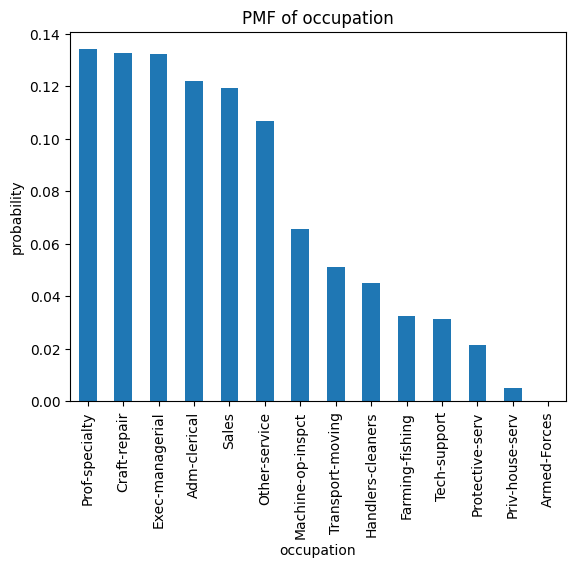

In [ ]:
#확률질량함수 2: 직업
import matplotlib.pyplot as plt

print('\n[PMF of occupation]')
occupation_dist=df['occupation'].value_counts(normalize=True) #value_counts()->각 항목이 몇 번 등장하는지 세기 
print(occupation_dist)                                       #normalize=True->전체 개수에서 해당 항목이 차지하는 비율(확률) 계산


plt.figure() #흰 바탕 만들기
occupation_dist.plot(kind='bar') #막대 그래프
plt.title('PMF of occupation')
plt.ylabel('probability')
plt.xticks(rotation=90) #항목 이름 90도 회전->세로로 표시
plt.show()

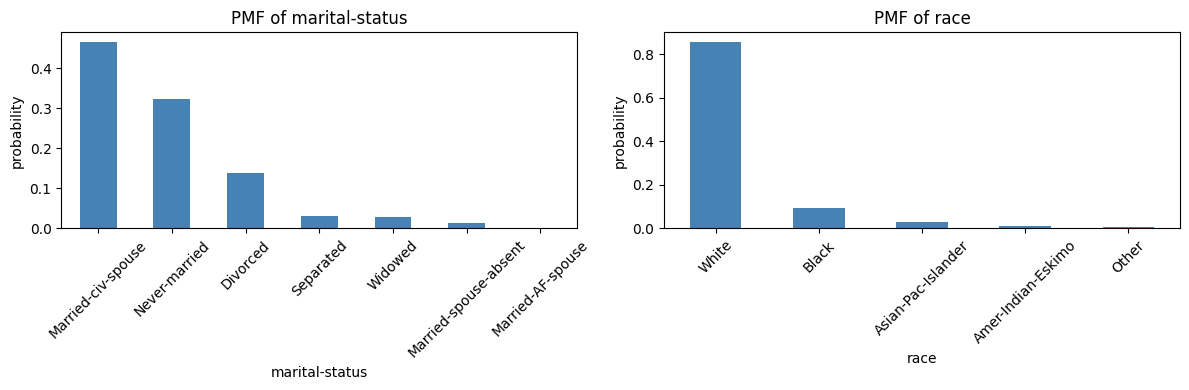

In [39]:
#확률질량함수 2개 시각화
fig, axes=plt.subplots(1,2,figsize=(12,4))

for ax, col in zip(axes, ['marital-status', 'race']):
    pmf=df[col].value_counts(normalize=True).sort_values(ascending=False)
    pmf.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'PMF of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('probability')
    ax.tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

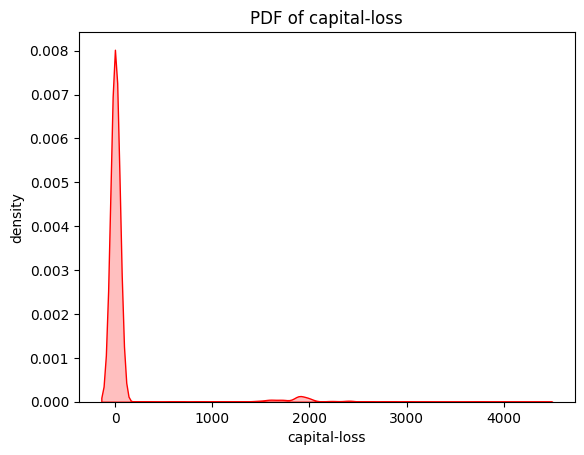

In [ ]:
#확률밀도함수 1: 자본 손실
import seaborn as sns

sns.kdeplot(df['capital-loss'],color='red', fill=True) #kdeplot->확률밀도함수
plt.title('PDF of capital-loss')
plt.xlabel('capital-loss')
plt.ylabel('density')
plt.show()

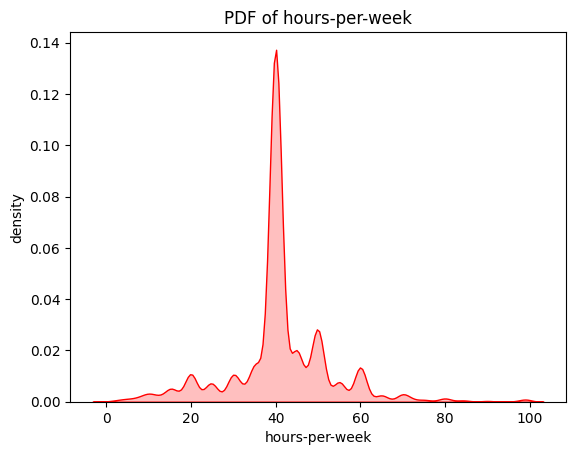

In [ ]:
#확률밀도함수 2: 주당 근로시간
import seaborn as sns

sns.kdeplot(df['hours-per-week'],color='red', fill=True) #kdeplot->확률밀도함수
plt.title('PDF of hours-per-week')
plt.xlabel('hours-per-week')
plt.ylabel('density')
plt.show()

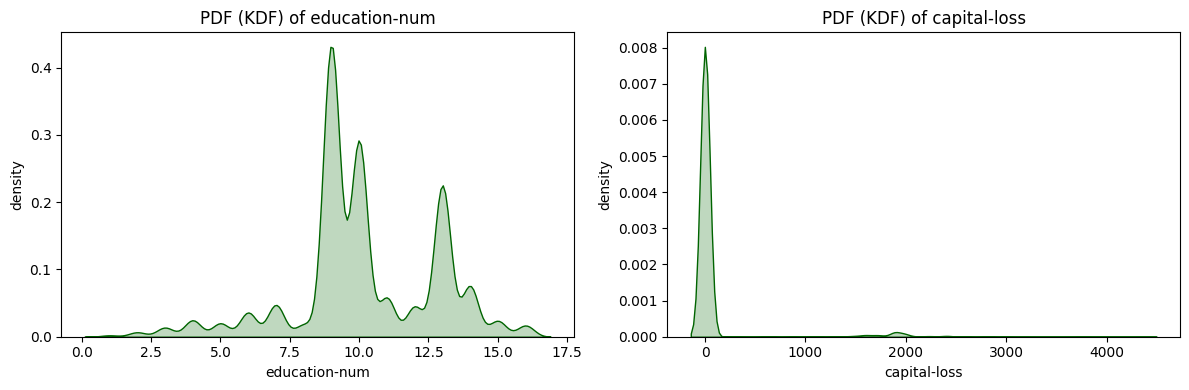

In [41]:
#확률밀도함수 2개 시각화
fig, axes=plt.subplots(1,2,figsize=(12,4))

for ax, col in zip(axes, ['education-num', 'capital-loss']):
    sns.kdeplot(df[col],ax=ax,fill=True,color='darkgreen')
    ax.set_title(f'PDF (KDF) of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('density')
plt.tight_layout()
plt.show()

In [ ]:
#Education 변수와 Income 변수 사이의 결합확률 구하기
edu_order=(df[['education', 'education-num']]
           .drop_duplicates() #중복 제거(고유 쌍만 남기기)
           .sort_values('education-num') #학력 이름 순이 아니라 학력 번호 순으로 정렬(초등학교-1<고등학교-9<학사-13)
           ['education']) #학력 이름만 추출

joint_prob=pd.crosstab(df['education'], df['income'], normalize='all').reindex(edu_order)

print('\n[결합확률표 P(education, income)]')
print(joint_prob)

print('\n결합확률의 전체 합:',joint_prob.to_numpy().sum())


[결합확률표 P(education, income)]
income           <=50K      >50K
education                       
Preschool     0.001564  0.000022
1st-4th       0.004801  0.000174
5th-6th       0.009624  0.000543
7th-8th       0.017075  0.001260
9th           0.014055  0.000869
10th          0.025112  0.001803
11th          0.033476  0.001955
12th          0.012013  0.000999
HS-grad       0.272305  0.052940
Some-college  0.174288  0.043729
Assoc-voc     0.031912  0.011057
Assoc-acdm    0.024439  0.008776
Bachelors     0.098169  0.070667
Masters       0.025199  0.031065
Prof-school   0.004432  0.013164
Doctorate     0.003411  0.009102

결합확률의 전체 합: 1.0


In [ ]:
#데이터 형태 확인
(df.head())

   age  workclass     education  education-num      marital-status  \
0   25    Private          11th              7       Never-married   
1   38    Private       HS-grad              9  Married-civ-spouse   
2   28  Local-gov    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  Some-college             10  Married-civ-spouse   
5   34    Private          10th              6       Never-married   

          occupation   race   sex  capital-gain  capital-loss  hours-per-week  \
0  Machine-op-inspct  Black  Male             0             0              40   
1    Farming-fishing  White  Male             0             0              50   
2    Protective-serv  White  Male             0             0              40   
3  Machine-op-inspct  Black  Male          7688             0              40   
5      Other-service  White  Male             0             0              30   

  income  
0  <=50K  
1  <=50K  
2   >50K  
3   >50K  
5  <=50K  


In [34]:
#Education-num이 14보다 크거나 같은 사건과 Income이 50k보다 큰 사건 사이의 조건부 확률 구하기
A=df['education-num']>=14
B=df['income']=='>50K'

ct=pd.crosstab(A,B,rownames=['edu_num>=14'], colnames=['income>50K']) #교차표 생성
print('[교차표 (빈도)]')
print(ct)
#P(Education|Income)

print('\n[조건부 확률]')
print(f'P(education-num>=14|income>50K)={(A&B).sum()/B.sum():.6f}')
print(f'P(income>50K|education-num>=14)={(A&B).sum()/A.sum():.6f}')

[교차표 (빈도)]
income>50K   False  True 
edu_num>=14              
False        33090   8967
True          1521   2455

[조건부 확률]
P(education-num>=14|income>50K)=0.214936
P(income>50K|education-num>=14)=0.617455


In [17]:
#수치형 변수 찾기
print(df.describe())

#데이터 타입 확인 방법
#print(df.info())

                age  education-num  capital-gain  capital-loss  hours-per-week
count  46033.000000   46033.000000  46033.000000  46033.000000    46033.000000
mean      38.556601      10.128929   1114.332653     88.729346       40.948407
std       13.204268       2.564064   7589.571484    405.316932       12.011069
min       17.000000       1.000000      0.000000      0.000000        1.000000
25%       28.000000       9.000000      0.000000      0.000000       40.000000
50%       37.000000      10.000000      0.000000      0.000000       40.000000
75%       47.000000      13.000000      0.000000      0.000000       45.000000
max       90.000000      16.000000  99999.000000   4356.000000       99.000000


In [ ]:
#모든 수치형 데이터에 대하여 공분산(Covariance), 상관계수(Correlation) 구하기

numeric_df=df[['age','education-num','capital-gain','capital-loss','hours-per-week']]

cov_matrix=numeric_df.cov() #numeric_df.cov->공분산 행렬
corr_matrix=numeric_df.corr() #numeric_df.corr->상관계수 행렬

print('\n[공분산 행렬]')
print(cov_matrix)

print('\n[상관계수 행렬]')
print(corr_matrix)


[공분산 행렬]
                        age  education-num  capital-gain   capital-loss  \
age              174.352685       1.271845  8.007864e+03     318.124211   
education-num      1.271845       6.574422  2.459421e+03      84.661612   
capital-gain    8007.864155    2459.420701  5.760160e+07  -98876.155815   
capital-loss     318.124211      84.661612 -9.887616e+04  164281.815366   
hours-per-week    16.206246       4.470243  7.564063e+03     270.407721   

                hours-per-week  
age                  16.206246  
education-num         4.470243  
capital-gain       7564.062545  
capital-loss        270.407721  
hours-per-week      144.265782  

[상관계수 행렬]
                     age  education-num  capital-gain  capital-loss  \
age             1.000000       0.037566      0.079907      0.059441   
education-num   0.037566       1.000000      0.126382      0.081463   
capital-gain    0.079907       0.126382      1.000000     -0.032142   
capital-loss    0.059441       0.081463     -0